# EDA: Before and After Prepare Data

This notebook analyzes the Womens Clothing E-Commerce Reviews dataset in two stages:
1. **Before prepare data** (raw CSV).
2. **After prepare data** (output of preprocessing pipeline and train/val/test splits).

If split files are missing, run:

```bash
python scripts/prepare_data.py
```

In [5]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing src/ and data/")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\Admin\Documents\Tuan_Huy\CO3133_DL


In [6]:
from src import config
from src.preprocessing import load_raw_data, clean_data, create_full_text

print("RAW_CSV:", config.RAW_CSV)
print("DATA_SPLITS_DIR:", config.DATA_SPLITS_DIR)
print("MIN_TOKEN_LENGTH:", config.MIN_TOKEN_LENGTH)

RAW_CSV: C:\Users\Admin\Documents\Tuan_Huy\CO3133_DL\data\raw\Womens Clothing E-Commerce Reviews.csv
DATA_SPLITS_DIR: C:\Users\Admin\Documents\Tuan_Huy\CO3133_DL\data\splits
MIN_TOKEN_LENGTH: 3


## 1) Before Prepare Data (Raw CSV)

In [7]:
raw_path = Path(config.RAW_CSV)
raw_original = pd.read_csv(raw_path, index_col=0)

print("Raw shape:", raw_original.shape)
display(raw_original.head(5))

Raw shape: (23486, 10)


,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [8]:
raw_profile = pd.DataFrame({
    "dtype": raw_original.dtypes.astype(str),
    "missing": raw_original.isna().sum(),
    "missing_pct": (raw_original.isna().mean() * 100).round(2),
    "n_unique": raw_original.nunique(dropna=True),
}).sort_values(["missing", "n_unique"], ascending=[False, False])

display(raw_profile)

,dtype,missing,missing_pct,n_unique
Title,object,3810,16.22,13993
Review Text,object,845,3.60,22634
Class Name,object,14,0.06,20
Department Name,object,14,0.06,6
Division Name,object,14,0.06,3
Clothing ID,int64,0,0.00,1206
Positive Feedback Count,int64,0,0.00,82
Age,int64,0,0.00,77
Rating,int64,0,0.00,5
Recommended IND,int64,0,0.00,2


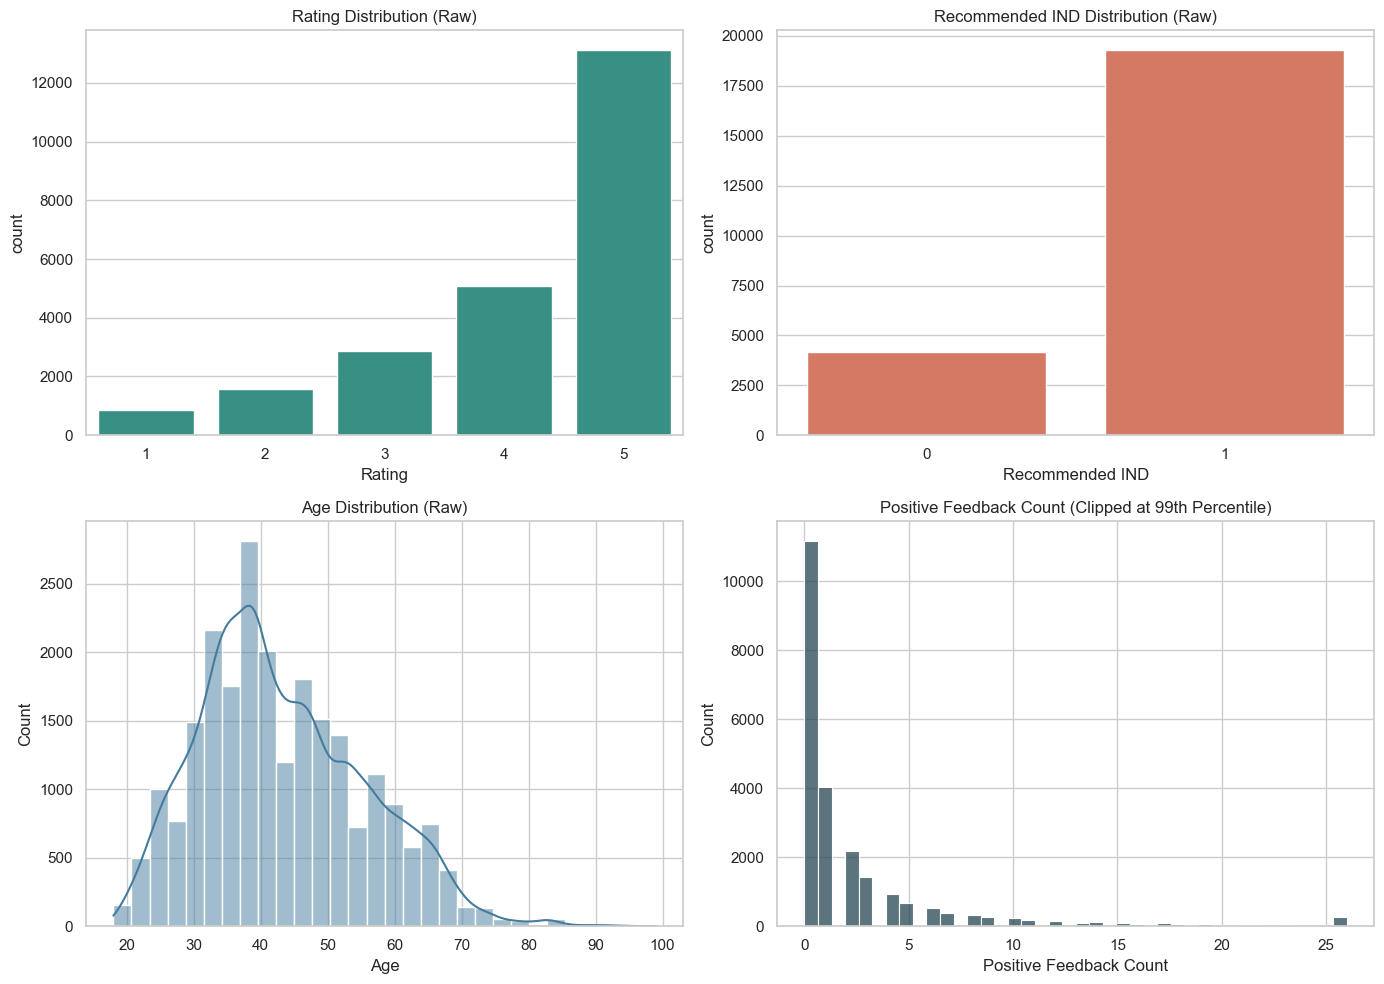

In [9]:
rating_series = pd.to_numeric(raw_original["Rating"], errors="coerce")
rec_series = pd.to_numeric(raw_original["Recommended IND"], errors="coerce")
age_series = pd.to_numeric(raw_original["Age"], errors="coerce").dropna()
feedback_series = pd.to_numeric(raw_original["Positive Feedback Count"], errors="coerce").dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rating_order = sorted(rating_series.dropna().astype(int).unique().tolist())
sns.countplot(x=rating_series.dropna().astype(int), order=rating_order, ax=axes[0, 0], color="#2a9d8f")
axes[0, 0].set_title("Rating Distribution (Raw)")
axes[0, 0].set_xlabel("Rating")

rec_order = sorted(rec_series.dropna().astype(int).unique().tolist())
sns.countplot(x=rec_series.dropna().astype(int), order=rec_order, ax=axes[0, 1], color="#e76f51")
axes[0, 1].set_title("Recommended IND Distribution (Raw)")
axes[0, 1].set_xlabel("Recommended IND")

sns.histplot(age_series, bins=30, kde=True, ax=axes[1, 0], color="#457b9d")
axes[1, 0].set_title("Age Distribution (Raw)")
axes[1, 0].set_xlabel("Age")

feedback_upper = feedback_series.quantile(0.99)
sns.histplot(feedback_series.clip(upper=feedback_upper), bins=40, ax=axes[1, 1], color="#264653")
axes[1, 1].set_title("Positive Feedback Count (Clipped at 99th Percentile)")
axes[1, 1].set_xlabel("Positive Feedback Count")

plt.tight_layout()
plt.show()

,count,mean,std,min,50%,75%,90%,95%,max
review_char_len,23486.0,297.581666,152.572686,0.0,292.0,451.0,500.0,500.0,508.0
review_token_len,23486.0,58.030869,30.176433,0.0,57.0,87.0,98.0,101.0,115.0
title_char_len,23486.0,15.998808,11.244639,0.0,15.0,23.0,31.0,37.0,52.0


Empty title ratio: 16.22%
Empty review ratio: 3.60%


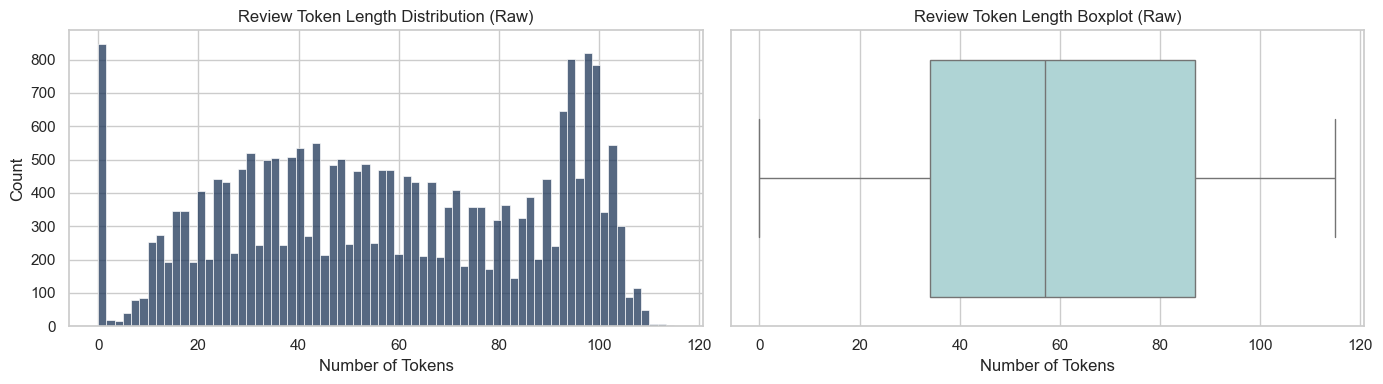

In [10]:
review_text_raw = raw_original["Review Text"].fillna("").astype(str)
title_text_raw = raw_original["Title"].fillna("").astype(str)

raw_text_stats = pd.DataFrame({
    "review_char_len": review_text_raw.str.len(),
    "review_token_len": review_text_raw.str.split().str.len(),
    "title_char_len": title_text_raw.str.len(),
})

display(raw_text_stats.describe(percentiles=[0.5, 0.75, 0.9, 0.95]).T)
print(f"Empty title ratio: {(title_text_raw.str.strip() == '').mean() * 100:.2f}%")
print(f"Empty review ratio: {(review_text_raw.str.strip() == '').mean() * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(raw_text_stats["review_token_len"], bins=70, ax=axes[0], color="#1d3557")
axes[0].set_title("Review Token Length Distribution (Raw)")
axes[0].set_xlabel("Number of Tokens")

sns.boxplot(x=raw_text_stats["review_token_len"], ax=axes[1], color="#a8dadc")
axes[1].set_title("Review Token Length Boxplot (Raw)")
axes[1].set_xlabel("Number of Tokens")

plt.tight_layout()
plt.show()

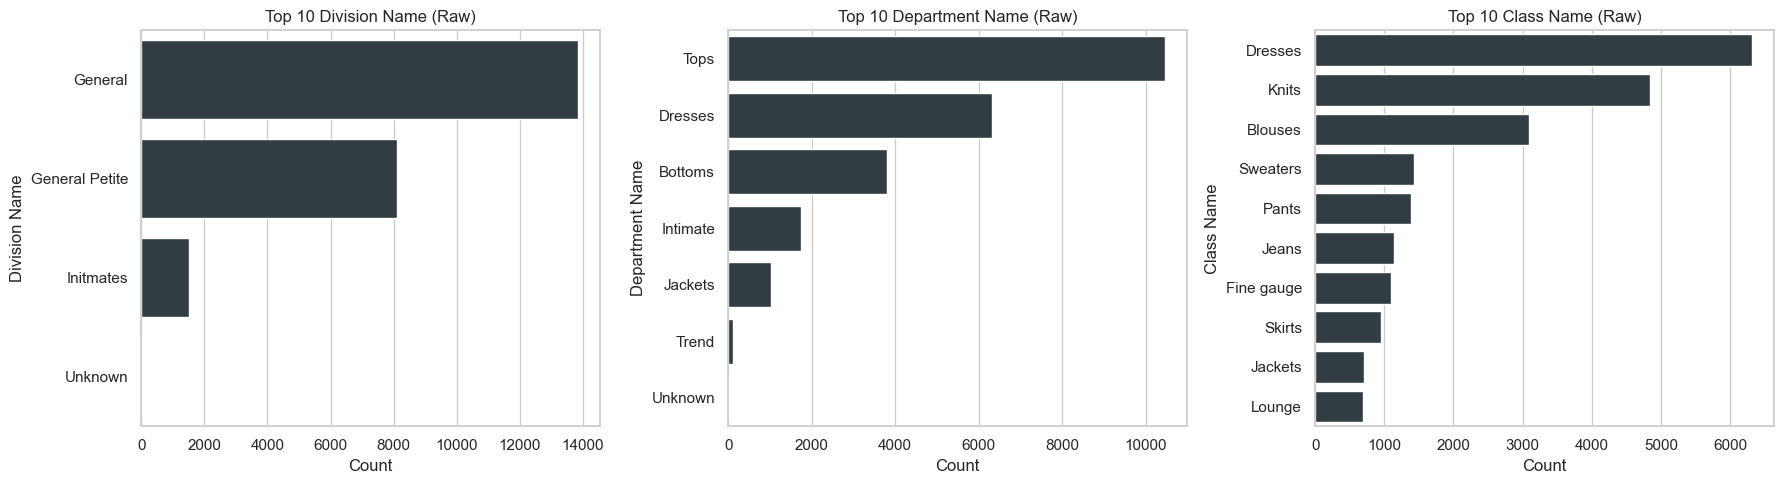

In [11]:
cat_cols = ["Division Name", "Department Name", "Class Name"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, cat_cols):
    top_counts = raw_original[col].fillna("Unknown").value_counts().head(10)
    sns.barplot(x=top_counts.values, y=top_counts.index, ax=ax, color="#2f3e46")
    ax.set_title(f"Top 10 {col} (Raw)")
    ax.set_xlabel("Count")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

## 2) After Prepare Data (Pipeline Output)

In [12]:
df_loaded = load_raw_data()
df_clean = clean_data(df_loaded.copy())
df_after = create_full_text(df_clean.copy())

pipeline_summary = pd.DataFrame([
    {"stage": "raw_original_csv", "rows": len(raw_original)},
    {"stage": "load_raw_data_renamed", "rows": len(df_loaded)},
    {"stage": "clean_data", "rows": len(df_clean)},
    {"stage": "create_full_text_and_label", "rows": len(df_after)},
])
pipeline_summary["removed_vs_prev"] = (pipeline_summary["rows"].shift(1) - pipeline_summary["rows"]).fillna(0).astype(int)
pipeline_summary["kept_pct_vs_raw"] = (pipeline_summary["rows"] / pipeline_summary.loc[0, "rows"] * 100).round(2)

display(pipeline_summary)

[2026-04-01 13:31:57] INFO - Loaded raw data: 23486 rows
[2026-04-01 13:31:57] INFO - After dropping missing review_text/rating: 22641 rows (removed 845)
[2026-04-01 13:31:57] INFO - After deduplication: 22636 rows (removed 5)
[2026-04-01 13:31:57] INFO - After removing short reviews (<3 tokens): 22628 rows (removed 8)


,stage,rows,removed_vs_prev,kept_pct_vs_raw
0,raw_original_csv,23486,0,100.00
1,load_raw_data_renamed,23486,0,100.00
2,clean_data,22628,858,96.35
3,create_full_text_and_label,22628,0,96.35


In [13]:
after_profile = pd.DataFrame({
    "dtype": df_after.dtypes.astype(str),
    "missing": df_after.isna().sum(),
    "missing_pct": (df_after.isna().mean() * 100).round(2),
    "n_unique": df_after.nunique(dropna=True),
}).sort_values(["missing", "n_unique"], ascending=[False, False])

display(after_profile)
display(df_after[["title", "review_text", "full_text", "rating", "label"]].head(5))

label_lookup = pd.DataFrame({
    "label": list(config.LABEL_MAP_INV.keys()),
    "rating": list(config.LABEL_MAP_INV.values()),
}).sort_values("label")
display(label_lookup)

,dtype,missing,missing_pct,n_unique
class_name,object,13,0.06,20
department,object,13,0.06,6
division,object,13,0.06,3
full_text,object,0,0.00,22628
review_text,object,0,0.00,22626
title,object,0,0.00,13988
clothing_id,int64,0,0.00,1177
feedback_count,int64,0,0.00,82
age,int64,0,0.00,77
rating,int32,0,0.00,5


,title,review_text,full_text,rating,label
0,,Absolutely wonderful - silky and sexy and comf...,Absolutely wonderful - silky and sexy and comf...,4,3
1,,Love this dress! it's sooo pretty. i happened ...,Love this dress! it's sooo pretty. i happened ...,5,4
2,Some major design flaws,I had such high hopes for this dress and reall...,Some major design flaws [SEP] I had such high ...,3,2
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...","My favorite buy! [SEP] I love, love, love this...",5,4
4,Flattering shirt,This shirt is very flattering to all due to th...,Flattering shirt [SEP] This shirt is very flat...,5,4


,label,rating
0,0,1
1,1,2
2,2,3
3,3,4
4,4,5


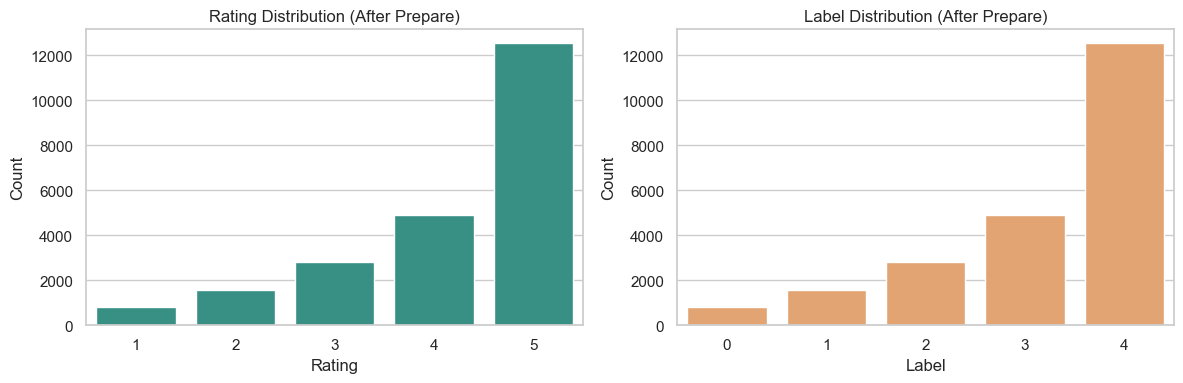

In [14]:
label_counts = df_after["label"].value_counts().sort_index()
rating_counts = df_after["rating"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=rating_counts.index.astype(str), y=rating_counts.values, ax=axes[0], color="#2a9d8f")
axes[0].set_title("Rating Distribution (After Prepare)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

sns.barplot(x=label_counts.index.astype(str), y=label_counts.values, ax=axes[1], color="#f4a261")
axes[1].set_title("Label Distribution (After Prepare)")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

,before_prepare,after_prepare
count,23486.000000,22628.000000
mean,58.030869,60.221363
std,30.176433,28.516968
min,0.000000,3.000000
50%,57.000000,59.000000
75%,87.000000,88.000000
90%,98.000000,98.000000
95%,101.000000,101.000000
max,115.000000,115.000000


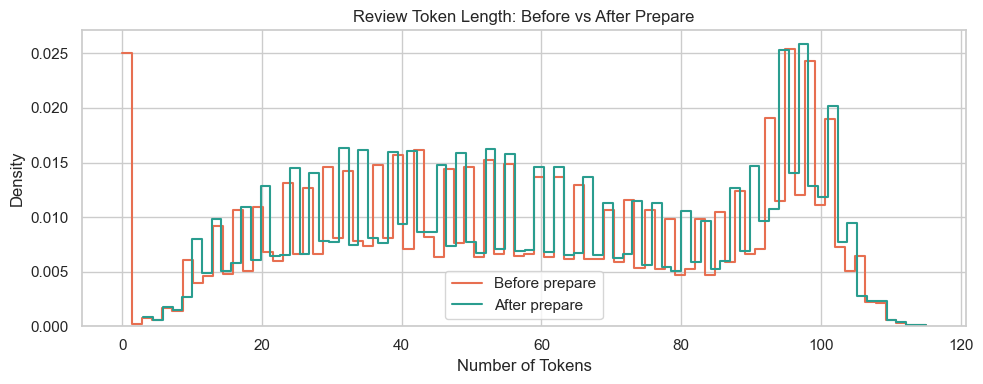

In [15]:
before_tokens = raw_original["Review Text"].fillna("").astype(str).str.split().str.len()
after_tokens = df_after["review_text"].fillna("").astype(str).str.split().str.len()

compare_len = pd.DataFrame({
    "before_prepare": before_tokens.describe(percentiles=[0.5, 0.75, 0.9, 0.95]),
    "after_prepare": after_tokens.describe(percentiles=[0.5, 0.75, 0.9, 0.95]),
})
display(compare_len)

plt.figure(figsize=(10, 4))
sns.histplot(before_tokens, bins=80, color="#e76f51", label="Before prepare", stat="density", element="step", fill=False)
sns.histplot(after_tokens, bins=80, color="#2a9d8f", label="After prepare", stat="density", element="step", fill=False)
plt.title("Review Token Length: Before vs After Prepare")
plt.xlabel("Number of Tokens")
plt.legend()
plt.tight_layout()
plt.show()

## 3) Prepared Train/Val/Test Splits

In [16]:
splits_dir = Path(config.DATA_SPLITS_DIR)
split_paths = {name: splits_dir / f"{name}.csv" for name in ["train", "val", "test"]}
missing_split_files = [str(path) for path in split_paths.values() if not path.exists()]

if missing_split_files:
    print("Missing split files:")
    for p in missing_split_files:
        print(" -", p)
    print("Run: python scripts/prepare_data.py")
    split_frames = {}
else:
    split_frames = {name: pd.read_csv(path) for name, path in split_paths.items()}
    for name, frame in split_frames.items():
        print(f"{name}: {frame.shape}")

train: (15839, 12)
val: (3394, 12)
test: (3395, 12)


In [17]:
if not split_frames:
    print("No split files loaded.")
else:
    split_size_table = pd.DataFrame({
        name: {"rows": len(df), "ratio_pct": round(len(df) / len(df_after) * 100, 2)}
        for name, df in split_frames.items()
    }).T
    display(split_size_table)

    expected_cols = ["title", "review_text", "rating", "full_text", "label"]
    for name, df in split_frames.items():
        missing_cols = [c for c in expected_cols if c not in df.columns]
        print(f"{name} missing expected columns: {missing_cols if missing_cols else 'None'}")

,rows,ratio_pct
train,15839.0,70.0
val,3394.0,15.0
test,3395.0,15.0


train missing expected columns: None
val missing expected columns: None
test missing expected columns: None


,train,val,test
label,,,
0,575,123,123
1,1084,233,232
2,1976,423,424
3,3435,736,736
4,8769,1879,1880


,train,val,test
label,,,
0,3.63,3.62,3.62
1,6.84,6.87,6.83
2,12.48,12.46,12.49
3,21.69,21.69,21.68
4,55.36,55.36,55.38


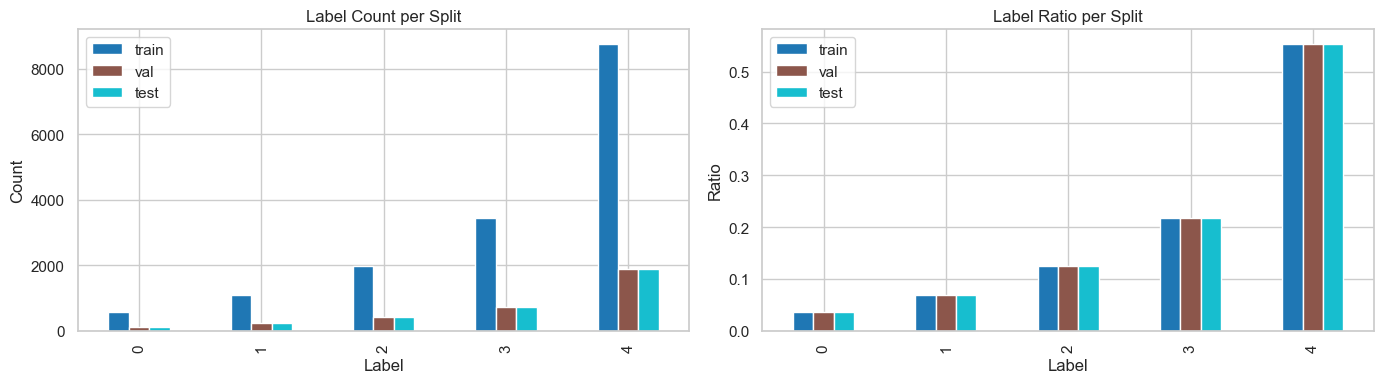

In [18]:
if not split_frames:
    print("No split files loaded.")
else:
    label_dist = pd.concat(
        [df["label"].value_counts().sort_index().rename(name) for name, df in split_frames.items()],
        axis=1
    ).fillna(0).astype(int)

    label_prop = label_dist.div(label_dist.sum(axis=0), axis=1).round(4)

    display(label_dist)
    display((label_prop * 100).round(2))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    label_dist.plot(kind="bar", ax=axes[0], colormap="tab10")
    axes[0].set_title("Label Count per Split")
    axes[0].set_xlabel("Label")
    axes[0].set_ylabel("Count")

    label_prop.plot(kind="bar", ax=axes[1], colormap="tab10")
    axes[1].set_title("Label Ratio per Split")
    axes[1].set_xlabel("Label")
    axes[1].set_ylabel("Ratio")

    plt.tight_layout()
    plt.show()

,rows,mean_tokens,median_tokens,p90_tokens,p95_tokens,max_tokens
split,,,,,,
train,15839,64.19,63,103,106,122
val,3394,62.66,60,103,106,120
test,3395,64.45,63,103,106,119


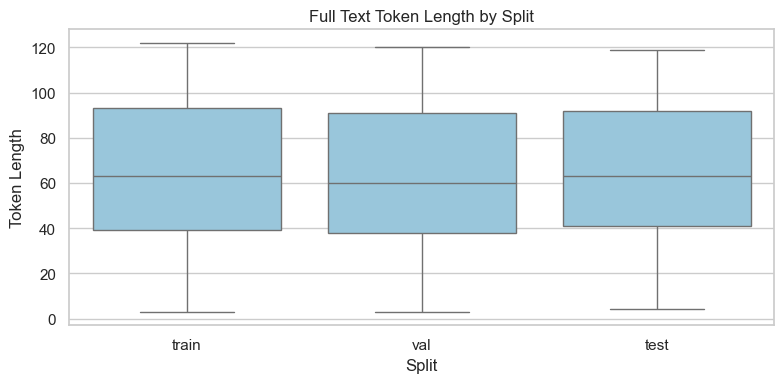

In [19]:
if not split_frames:
    print("No split files loaded.")
else:
    stats_rows = []
    length_long = []

    for name, df in split_frames.items():
        token_len = df["full_text"].fillna("").astype(str).str.split().str.len()
        stats_rows.append({
            "split": name,
            "rows": len(df),
            "mean_tokens": round(token_len.mean(), 2),
            "median_tokens": int(token_len.median()),
            "p90_tokens": int(token_len.quantile(0.90)),
            "p95_tokens": int(token_len.quantile(0.95)),
            "max_tokens": int(token_len.max()),
        })
        length_long.append(pd.DataFrame({"split": name, "token_len": token_len}))

    length_stats = pd.DataFrame(stats_rows).set_index("split")
    display(length_stats)

    length_long_df = pd.concat(length_long, ignore_index=True)
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=length_long_df, x="split", y="token_len", color="#8ecae6")
    plt.title("Full Text Token Length by Split")
    plt.xlabel("Split")
    plt.ylabel("Token Length")
    plt.tight_layout()
    plt.show()

## 4) Quick Checklist
- Raw data profile checked.
- Preprocessing impact quantified (rows kept/removed).
- New fields (`full_text`, `label`) verified.
- Train/val/test split quality verified (size, class ratio, text length).